# Numerical Optimization

 In this notebook we will review the concepts of:

 - Portfolio optimization through Lagrangage multipier method with Python
 - Mininum variance Portfolio
 - The efficient frontier
 - Portfolios in the efficient frontier (with and without inequalities)
 - Simulating the use of portfolio optimization

All with a portfolio example that includes popular tech assets BEFORE the AI boom in 2023, it is an exercise to see what a portfolio containing these now popular assets might look prior to their boom

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for optimization problems!
import cvxpy as cp
import scipy.optimize as opt

pd.set_option("display.max_columns", None)

# 1. Download historical financial data


In [2]:
ticker = "TSM"


assets = ["NVDA", "AMD", "TSM", "AVGO", "ASML", "MSFT", "GOOGL", "TLT"]

start_date = "2018-01-01"
end_date = "2026-07-30"

raw = yf.download(
    assets, start=start_date, end=end_date, auto_adjust=True, progress=False
)

X = raw["Close"]
X = X.loc[:"2022-11-30"]

X.tail()
# X.columns

Ticker,AMD,ASML,AVGO,GOOGL,MSFT,NVDA,TLT,TSM
Date,,,,,,,,
2022-11-23,76.400002,584.731812,50.414089,97.594612,240.726822,16.478159,88.939964,77.389938
2022-11-25,75.139999,573.101868,50.061714,96.603401,240.639282,16.229776,88.638489,76.851791
2022-11-28,73.190002,564.871155,49.334278,95.205788,235.067947,15.787870,88.888290,74.793617
2022-11-29,73.389999,560.494202,49.256802,94.353355,233.677505,15.600336,87.845993,74.897469
2022-11-30,77.629997,588.866455,52.056965,100.102379,248.077576,16.885483,88.492035,78.343498


# 2. Asset Allocation

In [3]:
# monthly_prices = X.resample(
#     "ME"
# ).last()  # we keep only the first and last monthly price
returns = X.pct_change().dropna()  # we use aritmetic returns!
returns.head()

Ticker,AMD,ASML,AVGO,GOOGL,MSFT,NVDA,TLT,TSM
Date,,,,,,,,
2018-01-03,0.051913,0.007596,0.010936,0.017061,0.004654,0.065814,0.004781,0.016821
2018-01-04,0.049351,0.009325,0.000334,0.003884,0.008801,0.005271,-0.000158,-0.005274
2018-01-05,-0.019802,0.011729,0.005925,0.013260,0.012398,0.008474,-0.002856,0.023379
2018-01-08,0.033670,0.005250,0.002393,0.003530,0.001020,0.030641,-0.000636,-0.000471
2018-01-09,-0.037459,-0.005386,-0.013847,-0.001274,-0.000680,-0.000270,-0.013372,-0.006126


<Axes: xlabel='Ticker', ylabel='Ticker'>

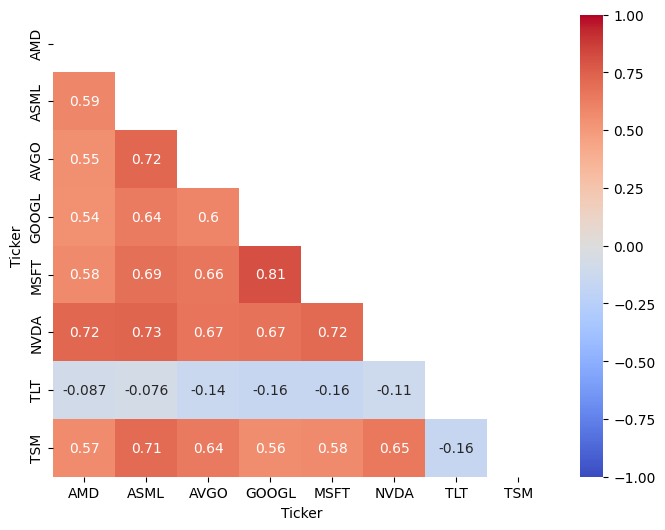

In [4]:
Corr = returns.corr()
mask = np.triu(np.ones_like(Corr, dtype=bool))
plt.figure(figsize=(8, 6))

sns.heatmap(Corr, mask=mask, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

In [5]:
returns.head()

Ticker,AMD,ASML,AVGO,GOOGL,MSFT,NVDA,TLT,TSM
Date,,,,,,,,
2018-01-03,0.051913,0.007596,0.010936,0.017061,0.004654,0.065814,0.004781,0.016821
2018-01-04,0.049351,0.009325,0.000334,0.003884,0.008801,0.005271,-0.000158,-0.005274
2018-01-05,-0.019802,0.011729,0.005925,0.013260,0.012398,0.008474,-0.002856,0.023379
2018-01-08,0.033670,0.005250,0.002393,0.003530,0.001020,0.030641,-0.000636,-0.000471
2018-01-09,-0.037459,-0.005386,-0.013847,-0.001274,-0.000680,-0.000270,-0.013372,-0.006126


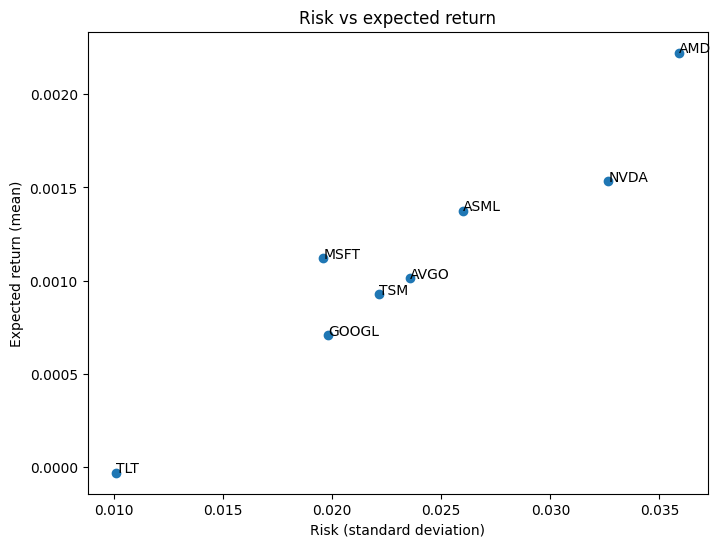

In [6]:
mu = returns.mean()
sigma = returns.std()

plt.figure(figsize=(8, 6))
plt.scatter(sigma, mu)

for asset in returns.columns:
    plt.text(sigma[asset], mu[asset], asset)

plt.xlabel("Risk (standard deviation)")
plt.ylabel("Expected return (mean)")
plt.title("Risk vs expected return")
plt.show()

# 3. Mininum Variance portfolio

We need a portfolio with weights that following: 
$$ w_{\text{char},1} = \frac{C^{-1}\iota} {\iota^T C^{-1}\iota} $$

and:
$$ \boxed{ w_\mu = \frac{\Sigma^{-1}\mu} {\iota^T\Sigma^{-1}\mu} } $$


In [7]:
sigma = returns.std().to_numpy()
Corr = returns.corr().to_numpy()
mu = returns.mean().to_numpy()
D = np.diag(sigma)
Covariance = D @ Corr @ D
df_Covariance = returns.cov().to_numpy()

In [8]:
iota = np.ones(len(assets))
inv_cov = np.linalg.inv(Covariance)
wchar_exp = (inv_cov @ iota) / (iota.T @ inv_cov @ iota)
print(f"Check for the sum of the weights: {wchar_exp.sum()}")
wchar_mu = (inv_cov @ mu) / (iota.T @ inv_cov @ mu)
print(f"Check for the sum of the weights: {wchar_mu.sum()}")

weights = pd.DataFrame(
    {"Minimum Variance": wchar_exp, "Mu Characteristic": wchar_mu},
    index=returns.columns,
)

Check for the sum of the weights: 1.0
Check for the sum of the weights: 1.0000000000000004


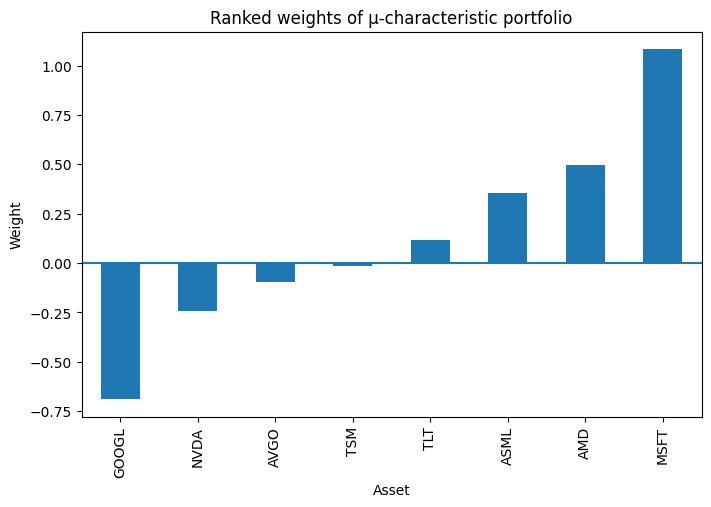

In [10]:
mu_weights = pd.Series(wchar_mu, index=returns.columns).sort_values()

mu_weights.plot(
    kind="bar", figsize=(8, 5), title="Ranked weights of μ-characteristic portfolio"
)

plt.ylabel("Weight")
plt.xlabel("Asset")
plt.axhline(0)
plt.show()

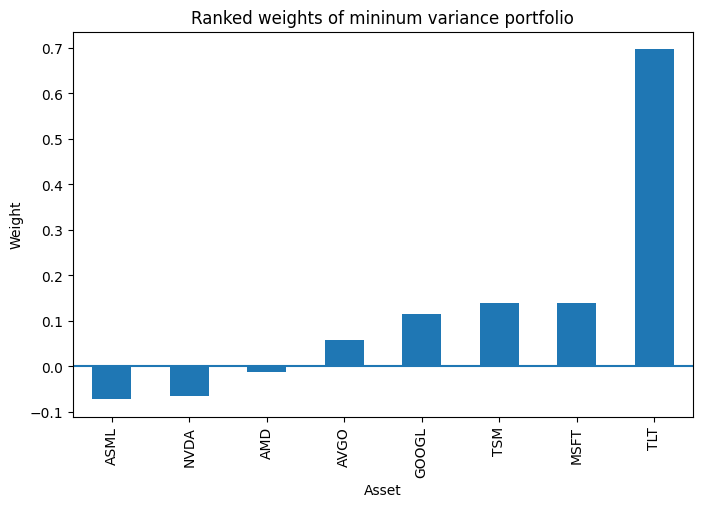

In [11]:
mu_weights = pd.Series(wchar_exp, index=returns.columns).sort_values()

mu_weights.plot(
    kind="bar", figsize=(8, 5), title="Ranked weights of mininum variance portfolio"
)

plt.ylabel("Weight")
plt.xlabel("Asset")
plt.axhline(0)
plt.show()

# Barrier frontier

## First lets solve for one specific level of return

In [20]:
w = cp.Variable(len(assets))
objecive = cp.Minimize(cp.quad_form(w, Covariance))
# we want to minimize the covariance matrix
target_return = 0.001

constraints = [cp.sum(w) == 1, mu @ w == target_return, w >= 0]

problem = cp.Problem(objecive, constraints)

print(problem.solve())

sigma = np.sqrt(w.value.T @ Covariance @ w.value)

sigma

0.00022175284735002215


np.float64(0.014891368216185582)

## Now we generalize for a set of returns

In [21]:
def mvef(Covariance, Mu, Npoints=100):
    """
    Compute the mean-variance efficient frontier

    constraints:
    1. sum of weights = 1
    2. portfolio expected return = target return
    3. 0 <= weight_i <= 1
    """

    Mu = np.asarray(Mu, dtype=float)
    Covariance = np.asarray(Covariance, dtype=float)

    Nu = len(Mu)

    epsilon = 0.0001

    # we create which targets returns test
    # we are just avoiding endpoint solutions
    mu_min = Mu.min() + epsilon * (Mu.mean() - Mu.min())
    mu_max = Mu.max() - epsilon * (Mu.max() - Mu.mean())
    mu_p = np.linspace(mu_min, mu_max, Npoints)

    # place holdres
    sigma_p = np.zeros(Npoints)
    weights = np.zeros((Npoints, Nu))

    for k, target_return in enumerate(mu_p):

        w = cp.Variable(Nu)

        objective = cp.Minimize(cp.quad_form(w, Covariance))

        constraints = [cp.sum(w) == 1, Mu @ w == target_return, w >= 0, w <= 1]

        problem = cp.Problem(objective, constraints)
        problem.solve()

        weights[k, :] = w.value

        # sqrt(variance) = portfolio standard deviation
        sigma_p[k] = np.sqrt(w.value.T @ Covariance @ w.value)

    result = pd.DataFrame({"sigma_p": sigma_p, "mu_p": mu_p})

    # Add portfolio weights as additional columns
    for i in range(Nu):
        result[f"w_{i}"] = weights[:, i]

    return result

In [22]:
Npoints = 100

MVEF = mvef(Covariance=Covariance, Mu=mu, Npoints=Npoints)

MVEF.head()

,sigma_p,mu_p,w_0,w_1,w_2,w_3,w_4,w_5,w_6,w_7
0,0.010074,-0.000031,-1.016911e-22,-5.669657e-23,-3.752310e-23,0.000154,-4.324259e-23,-6.507681e-23,0.999846,-3.292873e-23
1,0.009683,-0.000009,-9.401088e-23,-5.233813e-23,-3.458098e-23,0.030966,-3.988609e-23,-6.015795e-23,0.969034,-3.034935e-23
2,0.009333,0.000014,-8.640613e-23,-4.805573e-23,-3.171906e-23,0.061777,-3.654154e-23,-5.526420e-23,0.938223,-2.782425e-23
3,0.009028,0.000037,-7.862018e-23,-4.361701e-23,-2.873095e-23,0.092588,-3.318485e-23,-5.015472e-23,0.907412,-2.524191e-23
4,0.008773,0.000060,3.062525e-20,-9.413608e-21,9.233390e-21,0.117617,1.988594e-19,1.033858e-19,0.877925,4.458004e-03


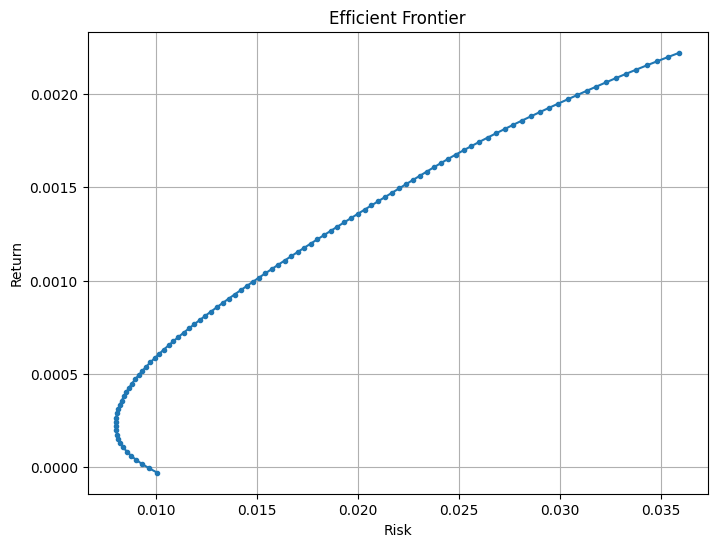

In [23]:
plt.figure(figsize=(8, 6))

plt.plot(MVEF["sigma_p"], MVEF["mu_p"], marker=".")

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.grid(True)

plt.show()

### Comparing against the barrier that allows negative weights

In [25]:
A = iota.T @ inv_cov @ iota
B = iota.T @ inv_cov @ mu
C_scalar = mu.T @ inv_cov @ mu

y = MVEF["mu_p"].to_numpy()

x = np.sqrt((A * y**2 - 2 * B * y + C_scalar) / (A * C_scalar - B**2))

NameError: name 'Sigma' is not defined

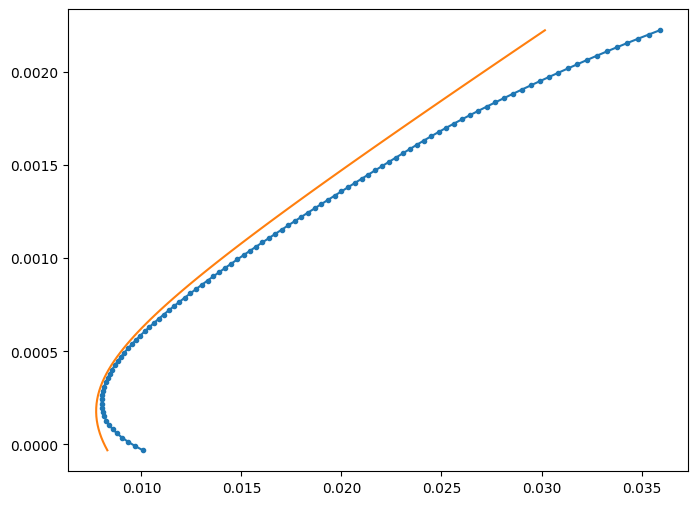

In [26]:
plt.figure(figsize=(8, 6))

# numerical frontier with no weight sign constraints
plt.plot(MVEF["sigma_p"], MVEF["mu_p"], marker=".", label="Long-only frontier")

plt.plot(x, y, label="Budget-only analytical frontier")

# Individual assets
plt.scatter(Sigma, mu, label="Individual assets")

for asset, sigma_i, mu_i in zip(returns.columns, Sigma, mu):
    plt.annotate(asset, (sigma_i, mu_i), xytext=(4, 4), textcoords="offset points")

plt.xlabel("Risk")
plt.ylabel("Expected Return")
plt.title("Mean-Variance Efficient Frontier")
plt.grid(True)
plt.legend()

plt.show()

## Portfolios in the efficient frontier

In [27]:
weight_cols = [f"w_{i}" for i in range(len(assets))]

MVEF = MVEF.rename(columns=dict(zip(weight_cols, assets)))
MVEF.columns

Index(['sigma_p', 'mu_p', 'NVDA', 'AMD', 'TSM', 'AVGO', 'ASML', 'MSFT',
       'GOOGL', 'TLT'],
      dtype='str')

In [28]:
MVEF_weights = (
    MVEF[assets]
    .reset_index(names="Point")
    .melt(id_vars="Point", var_name="Asset", value_name="Weight")
)

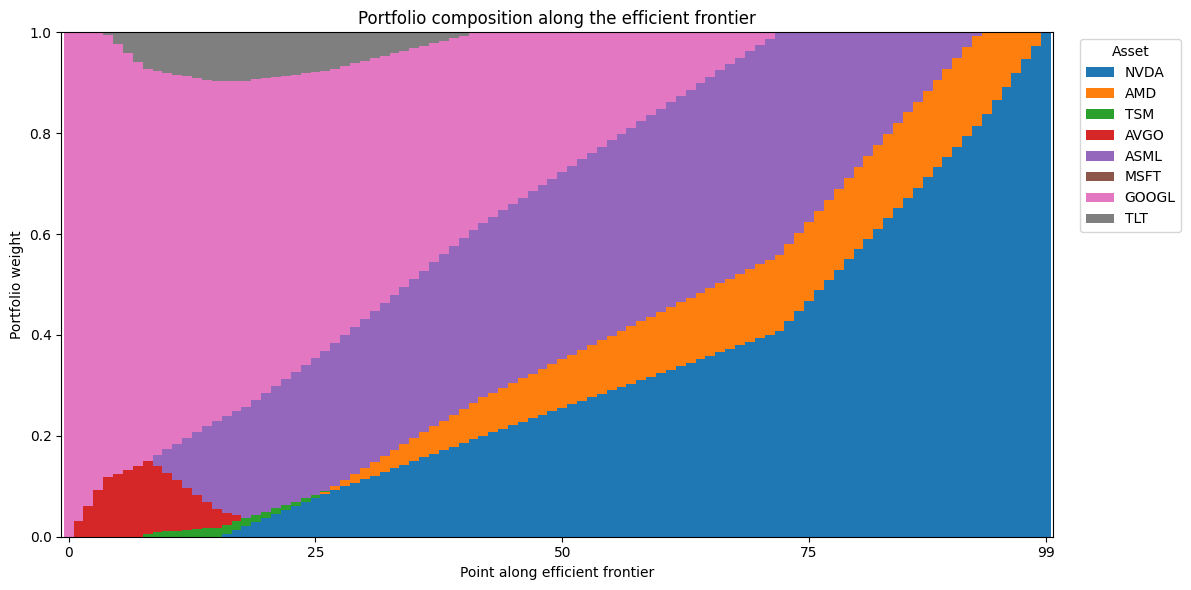

In [34]:
portfolio_weights = MVEF[assets].copy()

# Plot stacked portfolio composition
ax = portfolio_weights.plot(kind="bar", stacked=True, figsize=(12, 6), width=1)

ax.set_title("Portfolio composition along the efficient frontier")
ax.set_xlabel("Point along efficient frontier")
ax.set_ylabel("Portfolio weight")

# Show only a few x-axis labels
tick_positions = [0, 25, 50, 75, len(MVEF) - 1]

ax.set_xticks(tick_positions)
ax.set_xticklabels([str(i) for i in tick_positions], rotation=0)

ax.legend(title="Asset", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Efficient frontier in practice!

- What if our estimaned returns and volatilities are wrong because they coame from a specific historical data sample?

- We will use montecarlo simulation to pretend that our estimated mu and cov describe the "TRUE" market

- Ww will simulate a fake 18 year return history from that market

- re-estimate my and cov from the fake history

- build the efficient frontier using those simulated estimates

- Compare the resulting portfolio weights with the previous one

In [39]:
def mvmc(Covariance, Mu, Npoints=100, Freq=252, Years=5, seed=None):

    rng = np.random.default_rng(seed)

    Mu = np.asarray(Mu, dtype=float).reshape(-1)
    Covariance = np.asarray(Covariance, dtype=float)

    Nu = len(Mu)
    Nt = Years * Freq
    epsilon = 0.0001

    # simulating history

    L = np.linalg.cholesky(Covariance)

    # Independent standard normal shocks
    Z = rng.standard_normal((Nt, Nu))

    period_mu = Mu / Freq

    r_sim = period_mu + Z @ L.T / np.sqrt(Freq)

    Mu_sim = r_sim.mean(axis=0) * Freq

    Covariance_sim = np.cov(r_sim, rowvar=False) * Freq

    mu_min = Mu_sim.min() + epsilon * (Mu_sim.mean() - Mu_sim.min())

    mu_max = Mu_sim.max() - epsilon * (Mu_sim.max() - Mu_sim.mean())

    mu_sample = np.linspace(mu_min, mu_max, Npoints)

    # Store optimal portfolio weights
    sim_weights = np.zeros((Npoints, Nu))

    for k, target_return in enumerate(mu_sample):

        w = cp.Variable(Nu)

        objective = cp.Minimize(cp.quad_form(w, Covariance_sim))

        constraints = [cp.sum(w) == 1, Mu_sim @ w == target_return, w >= 0, w <= 1]

        problem = cp.Problem(objective, constraints)

        problem.solve()

        if w.value is None:
            sim_weights[k, :] = np.nan
        else:
            sim_weights[k, :] = w.value

    mu_p = sim_weights @ Mu

    sigma_p = np.zeros(Npoints)

    for k in range(Npoints):

        wk = sim_weights[k, :]

        if np.isnan(wk).any():
            sigma_p[k] = np.nan

        else:
            sigma_p[k] = np.sqrt(wk.T @ Covariance @ wk)

    result = pd.DataFrame({"mu_p": mu_p, "sigma_p": sigma_p})

    for i in range(Nu):
        result[f"w_{i}"] = sim_weights[:, i]

    return result

In [36]:
MC = mvmc(Covariance, mu, Npoints=100, Freq=12, Years=18, seed=42)

In [42]:
Mu_annual = mu * 252
Covariance_annual = Covariance * 252

MVMC = mvmc(Covariance_annual, Mu_annual, Npoints=100, Freq=252, Years=5, seed=42)

In [ ]:
Nsimulations = 100
Npoints = 100

sigma_sim = np.zeros((Npoints, Nsimulations))
mu_sim = np.zeros((Npoints, Nsimulations))

In [44]:
for n in range(Nsimulations):

    MVMC = mvmc(
        Covariance_annual, Mu_annual, Npoints=Npoints, Freq=252, Years=5, seed=n
    )

    sigma_sim[:, n] = MVMC["sigma_p"]
    mu_sim[:, n] = MVMC["mu_p"]

/var/folders/1f/54wv342x795c_zyzqlgyjjkw0000gn/T/ipykernel_70652/2424660762.py:75: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve()


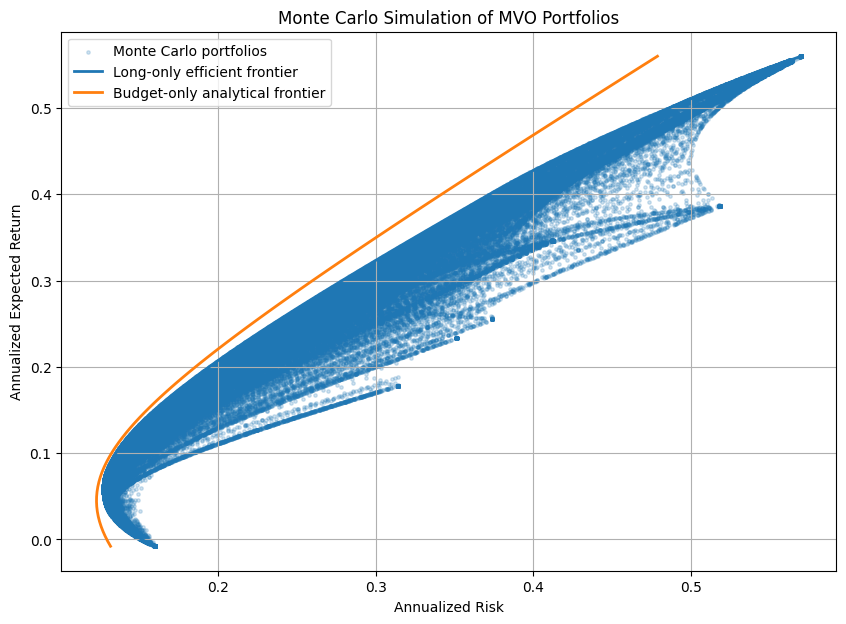

In [51]:
sigma_points = sigma_sim.flatten()
mu_points = mu_sim.flatten()
MVEF_annual = MVEF.copy()

MVEF_annual["mu_p"] = MVEF["mu_p"] * 252
MVEF_annual["sigma_p"] = MVEF["sigma_p"] * np.sqrt(252)
x_annual = x * np.sqrt(252)
y_annual = y * 252

plt.figure(figsize=(10, 7))

plt.scatter(sigma_points, mu_points, s=6, alpha=0.20, label="Monte Carlo portfolios")

plt.plot(
    MVEF_annual["sigma_p"],
    MVEF_annual["mu_p"],
    linewidth=2,
    label="Long-only efficient frontier",
)

plt.plot(x_annual, y_annual, linewidth=2, label="Budget-only analytical frontier")

plt.xlabel("Annualized Risk")
plt.ylabel("Annualized Expected Return")
plt.title("Monte Carlo Simulation of MVO Portfolios")
plt.grid(True)
plt.legend()
plt.show()

# What would happened if..?

In [52]:
# Find the point with the highest portfolio risk
riskiest_idx = MVEF["sigma_p"].idxmax()

# Extract its weights
w_risky = MVEF.loc[riskiest_idx, assets]

w_risky

NVDA     0.999923
AMD      0.000007
TSM      0.000010
AVGO     0.000013
ASML     0.000009
MSFT     0.000006
GOOGL    0.000019
TLT      0.000011
Name: 99, dtype: float64

In [60]:
future_prices = raw["Close"].loc["2022-12-01":"2026-06-30", assets].copy()

future_prices.head()

Ticker,NVDA,AMD,TSM,AVGO,ASML,MSFT,GOOGL,TLT
Date,,,,,,,,
2022-12-01,17.097010,77.480003,78.060280,52.030514,591.907043,247.640030,100.102379,91.318985
2022-12-02,16.838581,74.980003,76.946198,51.090515,586.532837,247.960892,99.557205,92.467384
2022-12-05,16.573174,73.620003,77.059486,50.130669,581.768677,243.274292,98.605637,91.172203
2022-12-06,15.951556,70.269997,75.114609,49.675320,574.273621,238.334900,96.127617,92.346519
2022-12-07,16.084263,70.139999,74.812477,48.983776,582.310913,237.605637,94.105553,94.522408


In [61]:
initial_capital = 10_000
normalized_prices = future_prices / future_prices.iloc[0]
portfolio_growth = normalized_prices @ w_risky

portfolio_value = initial_capital * portfolio_growth
portfolio_value.tail()

Date
2026-06-24    116388.864976
2026-06-25    114482.250492
2026-06-26    112604.806031
2026-06-29    114031.958321
2026-06-30    117026.506588
dtype: float64

In [62]:
final_value = portfolio_value.iloc[-1]

total_return = final_value / initial_capital - 1

print(f"Initial value: ${initial_capital:,.2f}")
print(f"Final value:   ${final_value:,.2f}")
print(f"Return:        {total_return:.2%}")

Initial value: $10,000.00
Final value:   $117,026.51
Return:        1070.27%


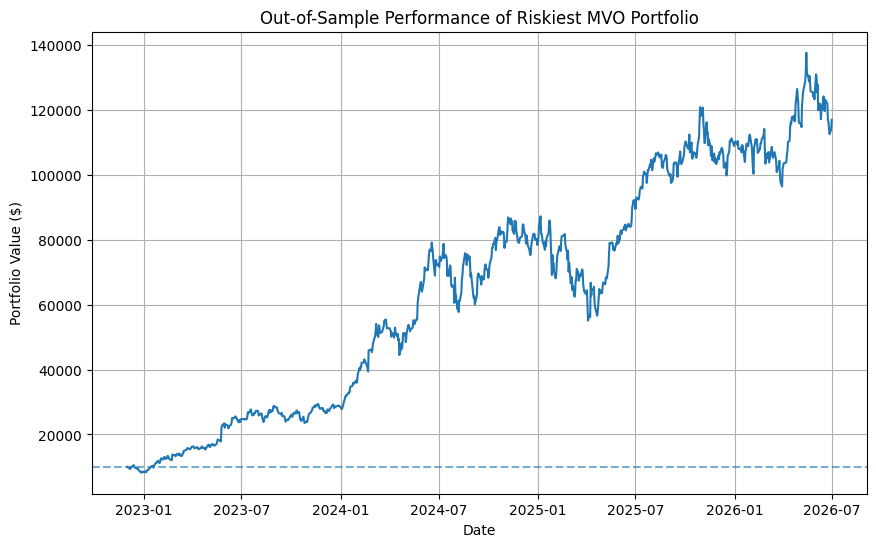

In [63]:
plt.figure(figsize=(10, 6))

plt.plot(portfolio_value.index, portfolio_value)

plt.axhline(initial_capital, linestyle="--", alpha=0.6)

plt.title("Out-of-Sample Performance of Riskiest MVO Portfolio")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.grid(True)

plt.show()